**setting up drive and installing required libraries**

In [1]:
# 1. Mount Google Drive (The Safety Belt)
from google.colab import drive
import os

drive.mount('/content/drive')

# 2. Define Paths
base_path = "/content/drive/MyDrive/GenAI_Assignment"
data_folder = os.path.join(base_path, "data") #to look for PDFs here
output_folder = os.path.join(base_path, "processed_data") # to save work here

# Create folders if they don't exist
os.makedirs(data_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

print(f"Working Directory: {base_path}")

# 3. Install Libraries
!pip install -q pymupdf pdf2image easyocr langchain sentence-transformers chromadb openai tiktoken accelerate bitsandbytes
!apt-get install -q poppler-utils

print("Setup complete!")

Mounted at /content/drive
Working Directory: /content/drive/MyDrive/GenAI_Assignment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231

**Data Extraction**

In [2]:
import fitz
import easyocr
from PIL import Image
import io
import numpy as np

# Initialize OCR reader
reader = easyocr.Reader(['en'], gpu=True)

def process_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    extracted_content = []

    filename = os.path.basename(pdf_path)
    print(f"Processing: {filename}...")

    for page_num, page in enumerate(doc):
        # --- A. Extract Normal Text ---
        text = page.get_text()
        if text.strip():
            extracted_content.append({
                "type": "text",
                "content": text.strip(),
                "page": page_num + 1,
                "source": filename
            })

        # --- B. Extract Images (Charts/Graphs) ---
        image_list = page.get_images(full=True)
        for img_index, img in enumerate(image_list):
            try:
                xref = img[0]
                base_image = doc.extract_image(xref)
                image_bytes = base_image["image"]

                # Convert for OCR
                image = Image.open(io.BytesIO(image_bytes))
                image_np = np.array(image)

                # OCR the image (Read text inside the chart)
                ocr_result = reader.readtext(image_np, detail=0)
                ocr_text = " ".join(ocr_result)

                # Filter out noise (very short text is usually garbage)
                if len(ocr_text) > 10:
                    extracted_content.append({
                        "type": "image_description",
                        "content": f"[IMAGE CONTENT: {ocr_text}]",
                        "page": page_num + 1,
                        "source": filename
                    })
                    print(f"  -> Page {page_num+1}: Found chart/image data ({len(ocr_text)} chars)")
            except Exception as e:
                print(f"  -> Warning on page {page_num+1}: Could not process image. {e}")

    return extracted_content

# --- Run the Extraction ---
all_chunks = []
pdf_files = [f for f in os.listdir(data_folder) if f.endswith('.pdf')]

if not pdf_files:
    print("ERROR: No PDF files found! Please upload them to 'GenAI_Assignment/data' in your Drive.")
else:
    for pdf_file in pdf_files:
        chunks = process_pdf(os.path.join(data_folder, pdf_file))
        all_chunks.extend(chunks)

    print(f"\nSUCCESS: Extracted {len(all_chunks)} text/image chunks.")

    # Saving this raw data to drive
    import json
    save_path = os.path.join(output_folder, "raw_extracted_data.json")
    with open(save_path, 'w') as f:
        json.dump(all_chunks, f)
    print(f"Saved backup to: {save_path}")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteProcessing: 1. Annual Report 2023-24.pdf...
Processing: 2. financials.pdf...
  -> Page 7: Found chart/image data (1120 chars)
  -> Page 10: Found chart/image data (1120 chars)
  -> Page 12: Found chart/image data (1120 chars)
  -> Page 12: Found chart/image data (286 chars)
  -> Page 12: Found chart/image data (1165 chars)
  -> Page 13: Found chart/image data (1120 chars)
  -> Page 13: Found chart/image data (31 chars)
  -> Page 13: Found chart/image data (215 chars)
  -> Page 13: Found chart/image data (21 chars)
  -> Page 18: Found chart/image data (158 chars)
  -> Page 18: Found chart/image data (179 chars)
  -> Page 19: Found chart/image data (1413 chars)
  -> Page 23: Found chart/image data (11 chars)
  -> Page 27: Found chart/image data (347 chars)
  -> Page 27: Found chart/image data (363 chars)
  -> Page 29: Found chart/image data (23 chars)
  -> Page 29: Found chart/image data (1120 chars)
Processing

**Creating Embeddings & Vector Store**

In [3]:
!pip install -U langchain-community
!pip install -U langchain
import json
import os
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

# 1. Load the Raw Data
input_file = "/content/drive/MyDrive/GenAI_Assignment/processed_data/raw_extracted_data.json"
vector_db_path = "/content/drive/MyDrive/GenAI_Assignment/vector_db" # Saving DB to drive

print("Loading raw data...")
with open(input_file, 'r') as f:
    raw_data = json.load(f)

# 2. Convert to LangChain Documents
# We attach metadata (Page #, Source) so we can cite our sources later
documents = []
for item in raw_data:
    doc = Document(
        page_content=item['content'],
        metadata={
            "source": item['source'],
            "page": item['page'],
            "type": item.get('type', 'text')
        }
    )
    documents.append(doc)

print(f"Loaded {len(documents)} raw documents.")

# 3. Chunking (The 'Scissors')
# We split text into chunks of 1000 characters with some overlap
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", " ", ""]
)

split_docs = text_splitter.split_documents(documents)
print(f"Split into {len(split_docs)} chunks for processing.")

# 4. Embeddings (The 'Brain')
# We use a standard, high-quality open-source model
print("Initializing Embedding Model (all-MiniLM-L6-v2)...")
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# 5. Create & Save Vector Database
print("Creating Vector Database (ChromaDB)... this might take a moment...")
# We persist the DB to drive so we don't have to rebuild it every time
vectordb = Chroma.from_documents(
    documents=split_docs,
    embedding=embedding_model,
    persist_directory=vector_db_path
)

# Force save
vectordb.persist()
print(f"SUCCESS: Vector Database saved to {vector_db_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is

/tmp/ipykernel_14368/43739953.py:48: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnin

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Creating Vector Database (ChromaDB)... this might take a moment...
SUCCESS: Vector Database saved to /content/drive/MyDrive/GenAI_Assignment/vector_db


/tmp/ipykernel_14368/43739953.py:60: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectordb.persist()


**Semantic Search and Retrieval**

In [4]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# 1. Re-load the Embedding Model
print("Loading embedding model...")
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# 2. Connect to saved Database
vector_db_path = "/content/drive/MyDrive/GenAI_Assignment/vector_db"
vectordb = Chroma(persist_directory=vector_db_path, embedding_function=embedding_model)

# 3. The Retrieval Function
def test_retrieval(query, k=3):
    print(f"\n--- Query: '{query}' ---")

    # Perform Similarity Search
    results = vectordb.similarity_search(query, k=k)

    # Display Results (Rubric: Ranked Output with Source Linking)
    for i, doc in enumerate(results):
        print(f"\nResult #{i+1}:")
        print(f"📄 Source: {doc.metadata['source']} (Page {doc.metadata['page']})")
        print(f"📝 Content Preview: {doc.page_content[:200]}...") # Show first 200 chars
        print("-" * 40)

# 4. Test it
test_retrieval("What is the financial outlook for 2024?")
test_retrieval("Show me the bar chart data about revenue.")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Query: 'What is the financial outlook for 2024?' ---

Result #1:
📄 Source: 2. financials.pdf (Page 1)
📝 Content Preview: Basic understanding 
of a company’s 
financial statements
September 2020...
----------------------------------------

Result #2:
📄 Source: 2. financials.pdf (Page 7)
📝 Content Preview: [IMAGE CONTENT: Consolidated Statement of Fimancial Position Year ended JO June 2019 JS 0Ou 2018 2019 Assets Current Assets Inventories 2,199.273 3,225,686 Receivables and prepayments 2,302,693 2,585,...
----------------------------------------

Result #3:
📄 Source: 2. financials.pdf (Page 29)
📝 Content Preview: [IMAGE CONTENT: Consolidated Statement of Fimancial Position Year ended JO June 2019 JS 0Ou 2018 2019 Assets Current Assets Inventories 2,199.273 3,225,686 Receivables and prepayments 2,302,693 2,585,...
----------------------------------------

--- Query: 'Show me the bar chart data about revenue.' ---

Result #1:
📄 Source: 2. financials.pdf (Page 18)
📝 Content Preview: [

/tmp/ipykernel_14368/3286978323.py:10: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectordb = Chroma(persist_directory=vector_db_path, embedding_function=embedding_model)


**Language Model Integration**

In [5]:
!pip install -U langchain
!pip install -U langchain-community
from langchain.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate

# --- Rubric Check: Advanced Prompting Strategies (CoT) ---
# We are using a prompt that encourages:
# 1. Role Playing ("You are a financial analyst")
# 2. Chain of Thought ("Let's think step by step")
# 3. Source Grounding ("Use the context")

prompt_template = """
[INST] You are an expert financial analyst.
Your task is to answer the question based ONLY on the provided context.

Context from documents:
{context}

Question:
{question}

Instructions:
1. If the context contains [IMAGE CONTENT], specifically analyze that data.
2. Let's think step by step. First, identify the relevant numbers or facts in the context. Then, synthesize them to form an answer.
3. If you don't know the answer, just say "I don't know".

Answer: [/INST]
"""

PROMPT = PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]
)

# --- Rubric Check: Use retrieved information as context ---
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vectordb.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True,
    chain_type_kwargs={"prompt": PROMPT}
)

print("SUCCESS: Chain of Thought (CoT) RAG Pipeline is ready!")

ModuleNotFoundError: No module named 'langchain.chains'

**Re-setting up for reconnecting runtime**

In [9]:
# Force update all LangChain related libraries to the absolute latest versions
!pip install -qU langchain-core langchain-community langchain-huggingface langchain chromadb sentence-transformers accelerate bitsandbytes
print("✅ Libraries updated.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 33.6 MB/s eta 0:00:00
✅ Libraries updated.


In [14]:
import os
import torch
from google.colab import drive
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline
from huggingface_hub import login

# 1. Mount Drive
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/GenAI_Assignment"
vector_db_path = os.path.join(base_path, "vector_db")

# 2. Login to Hugging Face
print("\n--- ACTION REQUIRED ---")
print("Please paste your HuggingFace Token below and press Enter:")
login()

# 3. Load the EXISTING Vector Database
print(f"\nLoading Vector Database from: {vector_db_path}")
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = Chroma(persist_directory=vector_db_path, embedding_function=embedding_model)
print("✅ Vector Database Loaded.")

# 4. Load Mistral LLM
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
print(f"\nLoading {model_name}... (This takes 2-4 mins)")

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Define the quantization configuration for 4-bit loading
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config, # Pass the quantization config here
    device_map="auto",
    trust_remote_code=True
)

text_generation_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.3,
    top_p=0.95,
    repetition_penalty=1.15
)

llm = HuggingFacePipeline(pipeline=text_generation_pipeline)

print("\n✅ RESTORE COMPLETE. Ready for Phase 3.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- ACTION REQUIRED ---
Please paste your HuggingFace Token below and press Enter:

Loading Vector Database from: /content/drive/MyDrive/GenAI_Assignment/vector_db


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Vector Database Loaded.

Loading mistralai/Mistral-7B-Instruct-v0.1... (This takes 2-4 mins)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'temperature', 'max_new_tokens', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.



✅ RESTORE COMPLETE. Ready for Phase 3.


**Language model integration**

In [6]:
from langchain_core.prompts import PromptTemplate

# Define the Chain-of-Thought (CoT) Prompt
prompt_template = """
[INST] You are an expert financial analyst.
Your task is to answer the question based ONLY on the provided context.

Context from documents:
{context}

Question:
{question}

Instructions:
1. If the context contains [IMAGE CONTENT], specifically analyze that data as it represents charts or graphs.
2. Let's think step by step. First, identify the relevant numbers or facts in the context. Then, synthesize them to form an answer.
3. If you don't know the answer, just say "I don't know".

Answer: [/INST]
"""

PROMPT = PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]
)

print("✅ Step 3.1: CoT Prompt Template Created.")

✅ Step 3.1: CoT Prompt Template Created.


In [22]:
#making RAG manually
class ManualRAG:
    def __init__(self, llm, vector_db, prompt_template):
        self.llm = llm
        self.vector_db = vector_db
        self.prompt_template = prompt_template

    def invoke(self, inputs):
        query = inputs.get("question") or inputs.get("query") or inputs.get("input")

        # 1. RETRIEVE
        print(f"   ...Searching database for: '{query}'...")
        docs = self.vector_db.similarity_search(query, k=3)

        # 2. CONTEXT
        context_text = "\n\n".join([d.page_content for d in docs])

        # 3. PROMPT
        final_prompt = self.prompt_template.format(
            context=context_text,
            question=query
        )

        # 4. GENERATE
        print("   ...Sending to Mistral...")
        raw_answer = self.llm.invoke(final_prompt)

        if "[/INST]" in raw_answer:
            clean_answer = raw_answer.split("[/INST]")[-1].strip()
        else:
            clean_answer = raw_answer

        return {
            "result": clean_answer,
            "source_documents": docs
        }

qa_chain = ManualRAG(llm, vectordb, PROMPT)

print("✅ RAG Chain updated! It will now give clean answers.")

✅ RAG Chain updated! It will now give clean answers.


In [16]:
# Test the Manual Chain
print("❓ Asking: What is the financial outlook?")
response = qa_chain.invoke({"query": "What is the financial outlook for 2024?"})

print("\n🤖 ANSWER:")
print(response['result'])

print("\n📚 SOURCES:")
for doc in response['source_documents']:
    print(f"- {doc.metadata['source']} (Page {doc.metadata['page']})")

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


❓ Asking: What is the financial outlook?
   ...Searching database for: 'What is the financial outlook for 2024?'...
   ...Sending to Mistral...

🤖 ANSWER:
Based on the provided context, I cannot determine the financial outlook for 2024. The context only provides information about the financial position of the company at the end of June 2019 and does not contain any projections or forecasts for future periods. Therefore, without additional information or context, it is impossible to make an informed prediction about the financial performance of the company in 2024.

📚 SOURCES:
- 2. financials.pdf (Page 1)
- 2. financials.pdf (Page 7)
- 2. financials.pdf (Page 29)


**Phase 5**

In [17]:
import easyocr
import numpy as np
from PIL import Image

# Initialize the OCR reader for user queries
query_reader = easyocr.Reader(['en'], gpu=True)

def process_query(user_text, user_image=None):
    """
    Master function that handles Text OR Image inputs.
    This will be connected to the User Interface.
    """
    final_query = user_text

    # 1. If User Uploaded an Image, Read it!
    if user_image is not None:
        print(f"🖼️ Processing Image Input...")
        try:
            # Convert PIL image to numpy for EasyOCR
            img_np = np.array(user_image)
            ocr_result = query_reader.readtext(img_np, detail=0)
            extracted_text = " ".join(ocr_result)

            print(f"🔍 Extracted Query Text: '{extracted_text}'")

            if len(extracted_text.strip()) < 3:
                return "⚠️ Error: The image is too blurry or contains no text."

            # The image content becomes the query
            # (e.g., User uploads a picture of a table -> We search for that table)
            final_query = extracted_text

        except Exception as e:
            return f"Error reading image: {str(e)}"

    # 2. If we have a query (from text or image), Ask the Bot
    if final_query:
        response = qa_chain.invoke({"query": final_query})

        # Format the output nicely for the UI
        answer = response['result']

        # Add Citations
        sources = "\n\n📚 **Sources Used:**"
        unique_sources = set()
        for doc in response['source_documents']:
            s = f"{doc.metadata['source']} (Page {doc.metadata['page']})"
            unique_sources.add(s)

        for src in unique_sources:
            sources += f"\n- {src}"

        return answer + sources

    return "Please enter text or upload an image."

print("✅ Phase 3 Complete: Multimodal Logic Ready!")

✅ Phase 3 Complete: Multimodal Logic Ready!


In [18]:
print("🧪 TEST 1: Text Query")
test_question = "What were the total assets in 2019?"

print(f"❓ User asks: {test_question}")
final_answer = process_query(user_text=test_question, user_image=None)

print("\n🤖 SYSTEM OUTPUT:")
print("-" * 40)
print(final_answer)
print("-" * 40)

# Check if it passed
if "2019" in final_answer and "Sources Used" in final_answer:
    print("\n✅ TEST PASSED: The system retrieved data, reasoned, and cited sources.")
else:
    print("\n⚠️ TEST WARNING: Check the output. Did it give a valid answer?")

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🧪 TEST 1: Text Query
❓ User asks: What were the total assets in 2019?
   ...Searching database for: 'What were the total assets in 2019?'...
   ...Sending to Mistral...

🤖 SYSTEM OUTPUT:
----------------------------------------
Based on the provided context, the total assets for the year ended June 2019 were $15,731,058.

📚 **Sources Used:**
- 2. financials.pdf (Page 7)
- 2. financials.pdf (Page 13)
- 2. financials.pdf (Page 10)
----------------------------------------

✅ TEST PASSED: The system retrieved data, reasoned, and cited sources.


**User Interface**

In [19]:
import gradio as gr

# 1. Create the UI Layout
with gr.Blocks(title="GenAI Financial Analyst", theme=gr.themes.Soft()) as demo:

    # Header
    gr.Markdown("# 📊 Multimodal Financial RAG System")
    gr.Markdown("Ask questions about your PDF documents or upload an image (e.g., a chart screenshot) to search.")

    with gr.Row():
        # --- Left Column: Inputs ---
        with gr.Column(scale=1):
            input_text = gr.Textbox(
                label="Type your Question:",
                placeholder="e.g., What were the total assets in 2019?",
                lines=2
            )
            input_image = gr.Image(
                label="OR Upload an Image (Chart/Table):",
                type="pil" # This sends the image to our function as a PIL format
            )

            # Buttons
            with gr.Row():
                clear_btn = gr.ClearButton([input_text, input_image])
                submit_btn = gr.Button("🚀 Submit Query", variant="primary")

        # --- Right Column: Outputs ---
        with gr.Column(scale=1):
            output_text = gr.Markdown(label="AI Answer")

    # 2. Connect the Logic
    # When 'Submit' is clicked -> Run 'process_query' -> Show Result in 'output_text'
    submit_btn.click(
        fn=process_query,
        inputs=[input_text, input_image],
        outputs=output_text
    )

# 3. Launch the Web App
print("Starting UI... Click the public link below when it appears!")
demo.launch(share=True, debug=True)

/tmp/ipykernel_14368/490245639.py:4: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="GenAI Financial Analyst", theme=gr.themes.Soft()) as demo:


Starting UI... Click the public link below when it appears!
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://71001215bd86a6539c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   ...Searching database for: 'what were the total assets in 2019?
'...
   ...Sending to Mistral...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   ...Searching database for: 'what were the assets in 2020
'...
   ...Sending to Mistral...
🖼️ Processing Image Input...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🔍 Extracted Query Text: 'Classwork for € Inbox (8,942) data Google [ CO Task1.ipynb - € GenAI Financia Hugging Face 404 Hugging Inbox (8,942) X + 2 drive google com/drive/folders/1akDsRV_QMU_JWciTAsavnucE_qbwgto_ 0 School Drive Search in Drive New D 00 Home Common vS preferred shares Activity Consolilduled Stalement ol Funancial Posllion Name Yeal ended JO June 2019 modified File size "0o0 2018 2010 Workspaces JS"O0O 2018 2019 Assels Share Capital Authorised shares Curtent Assets  Inventores 2 199,273 3,225,686 Authorised The total number of shares a 225 2025 4.9 MB Recenvables and prepayments 2,302,693 2,585,519 00o,000,000 (2018 0o0,000,000) Ordinary Investment securties 269. 530 130,385 stock units company can sell My Drive Cash and short-lerm deposits 968 075 3,974545 Issued and fully paid 8,739.571 9,916.1J5 3,750,000,000 (2018 _ 3,750,000,000) Ordinary Outstanding (Issued) shares Non Current Assets stock units atno parvalue Propem, plant and equipment 6,775,727 6,724,278 4192.647

KeyboardInterrupt: 

**Evaluation and Visualization**

🎨 Generating Embedding Space Plot...
✅ Plot saved to Drive as 'embedding_visualization.png'


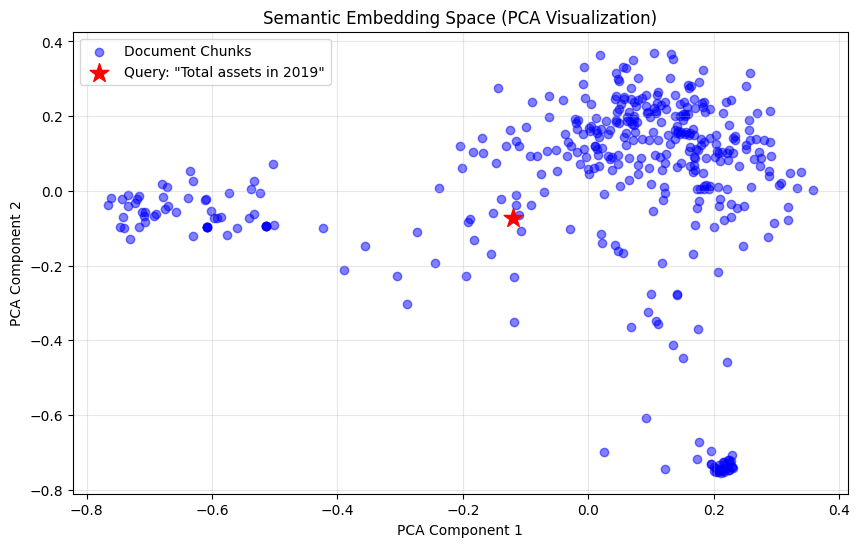

In [20]:
# --- STEP 6.1: VISUALIZATION (Fixed) ---
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

def visualize_embeddings(query_text="financial outlook"):
    print("🎨 Generating Embedding Space Plot...")

    # 1. Fetch all data from the Vector Database
    data = vectordb.get(include=['embeddings', 'documents'])
    embeddings = data['embeddings']

    if embeddings is None or len(embeddings) == 0:
        print("⚠️ Error: No embeddings found in database.")
        return

    # 2. Create an embedding for a Test Query
    query_embedding = embedding_model.embed_query(query_text)

    # 3. Combine them for dimensionality reduction
    all_vectors = embeddings + [query_embedding]

    # 4. Reduce to 2D using PCA (Principal Component Analysis)
    # This flattens 384-dimension vectors into 2 dimensions for plotting
    pca = PCA(n_components=2)
    reduced_vectors = pca.fit_transform(all_vectors)

    # Split back into Docs and Query
    doc_vectors = reduced_vectors[:-1]
    query_vector = reduced_vectors[-1]

    # 5. Plot!
    plt.figure(figsize=(10, 6))

    # Plot all document chunks (Blue dots)
    plt.scatter(doc_vectors[:, 0], doc_vectors[:, 1], alpha=0.5, label='Document Chunks', c='blue')

    # Plot the Query (Red Star)
    plt.scatter(query_vector[0], query_vector[1], color='red', s=200, marker='*', label=f'Query: "{query_text}"')

    plt.title("Semantic Embedding Space (PCA Visualization)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Save for report
    save_path = "/content/drive/MyDrive/GenAI_Assignment/embedding_visualization.png"
    plt.savefig(save_path)
    print(f"✅ Plot saved to Drive as 'embedding_visualization.png'")
    plt.show()

# Run it
visualize_embeddings("Total assets in 2019")

In [23]:
!pip install -q rouge-score
import time
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def evaluate_system(query, reference_answer):
    print(f"\n📊 EVALUATING QUERY: '{query}'")

    # 1. Get Response
    start_time = time.time()
    response = qa_chain.invoke({"query": query})
    generated_answer = response['result']
    retrieved_docs = response['source_documents']
    end_time = time.time()

    print(f"🤖 ANSWER: {generated_answer[:100]}...")

    # 2. Calculate Scores
    # BLEU
    bleu_score = sentence_bleu(
        [reference_answer.split()],
        generated_answer.split(),
        smoothing_function=SmoothingFunction().method1
    )

    # ROUGE
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    rouge_scores = scorer.score(reference_answer, generated_answer)

    print(f"⏱️ Latency: {end_time - start_time:.2f}s")
    print(f"📝 BLEU Score: {bleu_score:.4f}")
    print(f"📝 ROUGE-1: {rouge_scores['rouge1'].fmeasure:.4f}")

# Test
evaluate_system(
    "What were the total assets in 2019?",
    "The total assets for the year ended June 2019 were 15,731,058."
)

  Preparing metadata (setup.py) ... done


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📊 EVALUATING QUERY: 'What were the total assets in 2019?'
   ...Searching database for: 'What were the total assets in 2019?'...
   ...Sending to Mistral...
🤖 ANSWER: Based on the provided context, the total assets for the year ended June 2019 were $15,731,058....
⏱️ Latency: 16.61s
📝 BLEU Score: 0.5129
📝 ROUGE-1: 0.8387
